# Hierarchical splitting methods 
## Application to the rigid body equations

Author: Kevin Schäfers, kschaefers@uni-wuppertal.de
Date: 15.01.2026

---------------------------------------------------

This Jupyter notebook implements the hierarchical splitting methods used in 

*K. Schäfers, M. Günther: A hierarchical splitting approach for N-split ordinary differential equations*

to perform the numerical simulations for the rigid body equations. Moreover, this Jupyter notebook contains the scripts with which the numerical results have been obtained. For the numerical results reported in the paper, we have executed this Jupyter notebook with Python version 3.13.0 on a MacBook Pro 2021 with M1 Pro chip.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import time
import matplot2tikz # convert pyplot to tikz, see https://github.com/ErwindeGelder/matplot2tikz

In [ ]:
I = np.array([2,1,2/3]) # principal moments of inertia
tspan = np.array([0,int(1e+2)]) # time interval [0,100]
x0 = np.array([np.cos(1.1),0,np.sin(1.1)]) # initial values situated on the unit sphere

## Implementation of the methods

In [3]:
# Flows of the three subsystems
def flow1(x,h):
    theta = h*x[0]/I[0]
    cos_value = np.cos(theta)
    sin_value = np.sin(theta)
    return np.array([x[0],cos_value*x[1]+sin_value*x[2],-sin_value*x[1]+cos_value*x[2]])

def flow2(x,h):
    theta = h*x[1]/I[1]
    cos_value = np.cos(theta)
    sin_value = np.sin(theta)
    return np.array([cos_value*x[0]-sin_value*x[2],x[1],sin_value*x[0]+cos_value*x[2]])

def flow3(x,h):
    theta = h*x[2]/I[2]
    cos_value = np.cos(theta)
    sin_value = np.sin(theta)
    return np.array([cos_value*x[0]+sin_value*x[1],-sin_value*x[0]+cos_value*x[1],x[2]])

### Strang splitting

In [4]:
# Strang splitting of order p=2
def Strang(x0,tspan,nsteps):
    h = (tspan[1]-tspan[0])/nsteps
    t = np.linspace(tspan[0],tspan[1],nsteps+1)
    x = np.zeros((len(x0),nsteps+1))
    x[:,0] = x0

    for n in range(nsteps):
        x[:,n+1] = flow1(x[:,n],h/2)
        x[:,n+1] = flow2(x[:,n+1],h/2)
        x[:,n+1] = flow3(x[:,n+1],h)
        x[:,n+1] = flow2(x[:,n+1],h/2)
        x[:,n+1] = flow1(x[:,n+1],h/2)

    return t,x

### Implementation of the four hierarchical Yoshida methods 

In [ ]:
# Yoshida 7a, from a mathematical p.o.v. equivalent to Yoshida9a
def Yoshida7a(x0,tspan,nsteps):
    h = (tspan[1]-tspan[0])/nsteps
    t = np.linspace(tspan[0],tspan[1],nsteps+1)
    x = np.zeros((len(x0),nsteps+1))
    x[:,0] = x0

    gamma1 = 1/(2-2.0**(1/3))
    gamma2 = 1-2*gamma1

    for n in range(nsteps):
        x[:,n+1] = flow1(x[:,n],gamma1*h/2)

        x[:,n+1] = flow2(x[:,n+1],gamma1*h/2)
        x[:,n+1] = flow3(x[:,n+1],gamma1*h)
        x[:,n+1] = flow2(x[:,n+1],gamma1*h/2)

        x[:,n+1] = flow1(x[:,n+1],(gamma1+gamma2)*h/2)

        x[:,n+1] = flow2(x[:,n+1],gamma2*h/2)
        x[:,n+1] = flow3(x[:,n+1],gamma2*h)
        x[:,n+1] = flow2(x[:,n+1],gamma2*h/2)

        x[:,n+1] = flow1(x[:,n+1],(gamma2+gamma1)*h/2)

        x[:,n+1] = flow2(x[:,n+1],gamma1*h/2)
        x[:,n+1] = flow3(x[:,n+1],gamma1*h)
        x[:,n+1] = flow2(x[:,n+1],gamma1*h/2)

        x[:,n+1] = flow1(x[:,n+1],gamma1*h/2)   

    return t,x

# Yoshida9a, from a mathematical p.o.v. equivalent to Yoshida7a but Yoshida9a uses more (unnecessary) 
# evaluations of the first flow, resulting in a less efficient computational process
def Yoshida9a(x0,tspan,nsteps):
    h = (tspan[1]-tspan[0])/nsteps
    t = np.linspace(tspan[0],tspan[1],nsteps+1)
    x = np.zeros((len(x0),nsteps+1))
    x[:,0] = x0

    gamma1 = 1/(2-2.0**(1/3))
    gamma2 = 1-2*gamma1

    for n in range(nsteps):
        x[:,n+1] = flow1(x[:,n],gamma1*h/2)

        x[:,n+1] = flow2(x[:,n+1],gamma1*h/2)
        x[:,n+1] = flow3(x[:,n+1],gamma1*h)
        x[:,n+1] = flow2(x[:,n+1],gamma1*h/2)

        x[:,n+1] = flow1(x[:,n+1],gamma1*h/2)
        x[:,n+1] = flow1(x[:,n+1],gamma2*h/2)

        x[:,n+1] = flow2(x[:,n+1],gamma2*h/2)
        x[:,n+1] = flow3(x[:,n+1],gamma2*h)
        x[:,n+1] = flow2(x[:,n+1],gamma2*h/2)

        x[:,n+1] = flow1(x[:,n+1],gamma2*h/2)
        x[:,n+1] = flow1(x[:,n+1],gamma1*h/2)

        x[:,n+1] = flow2(x[:,n+1],gamma1*h/2)
        x[:,n+1] = flow3(x[:,n+1],gamma1*h)
        x[:,n+1] = flow2(x[:,n+1],gamma1*h/2)

        x[:,n+1] = flow1(x[:,n+1],gamma1*h/2)   

    return t,x

# Yoshida9b, convergence order p=4
def Yoshida9b(x0,tspan,nsteps):
    h = (tspan[1]-tspan[0])/nsteps
    t = np.linspace(tspan[0],tspan[1],nsteps+1)
    x = np.zeros((len(x0),nsteps+1))
    x[:,0] = x0

    gamma1 = 1/(2-2.0**(1/3))
    gamma2 = 1-2*gamma1

    

    for n in range(nsteps):
        x[:,n+1] = flow2(x[:,n],gamma1*h/4)
        x[:,n+1] = flow3(x[:,n+1],gamma1*h/2)
        x[:,n+1] = flow2(x[:,n+1],gamma1*h/4)
        x[:,n+1] = flow1(x[:,n+1],gamma1*h)
        x[:,n+1] = flow2(x[:,n+1],gamma1*h/4)
        x[:,n+1] = flow3(x[:,n+1],gamma1*h/2)
        x[:,n+1] = flow2(x[:,n+1],gamma1*h/4)

        x[:,n+1] = flow2(x[:,n+1],gamma2*h/4)
        x[:,n+1] = flow3(x[:,n+1],gamma2*h/2)
        x[:,n+1] = flow2(x[:,n+1],gamma2*h/4)
        x[:,n+1] = flow1(x[:,n+1],gamma2*h)
        x[:,n+1] = flow2(x[:,n+1],gamma2*h/4)
        x[:,n+1] = flow3(x[:,n+1],gamma2*h/2)
        x[:,n+1] = flow2(x[:,n+1],gamma2*h/4)

        x[:,n+1] = flow2(x[:,n+1],gamma1*h/4)
        x[:,n+1] = flow3(x[:,n+1],gamma1*h/2)
        x[:,n+1] = flow2(x[:,n+1],gamma1*h/4)
        x[:,n+1] = flow1(x[:,n+1],gamma1*h)
        x[:,n+1] = flow2(x[:,n+1],gamma1*h/4)
        x[:,n+1] = flow3(x[:,n+1],gamma1*h/2)
        x[:,n+1] = flow2(x[:,n+1],gamma1*h/4)

    return t,x

# Yoshida7b, convergence order p=2 
def Yoshida7b(x0,tspan,nsteps):
    h = (tspan[1]-tspan[0])/nsteps
    t = np.linspace(tspan[0],tspan[1],nsteps+1)
    x = np.zeros((len(x0),nsteps+1))
    x[:,0] = x0

    gamma1 = 1/(2-2.0**(1/3))
    gamma2 = 1-2*gamma1

    for n in range(nsteps):
        x[:,n+1] = flow2(x[:,n],gamma1*h/4)
        x[:,n+1] = flow3(x[:,n+1],gamma1*h/2)
        x[:,n+1] = flow2(x[:,n+1],gamma1*h/4)

        x[:,n+1] = flow1(x[:,n+1],gamma1*h)

        x[:,n+1] = flow2(x[:,n+1],(gamma1+gamma2)*h/4)
        x[:,n+1] = flow3(x[:,n+1],(gamma1+gamma2)*h/2)
        x[:,n+1] = flow2(x[:,n+1],(gamma1+gamma2)*h/4)

        x[:,n+1] = flow1(x[:,n+1],gamma2*h)

        x[:,n+1] = flow2(x[:,n+1],(gamma2+gamma1)*h/4)
        x[:,n+1] = flow3(x[:,n+1],(gamma2+gamma1)*h/2)
        x[:,n+1] = flow2(x[:,n+1],(gamma2+gamma1)*h/4)

        x[:,n+1] = flow1(x[:,n+1],gamma1*h)

        x[:,n+1] = flow2(x[:,n+1],gamma1*h/4)
        x[:,n+1] = flow3(x[:,n+1],gamma1*h/2)
        x[:,n+1] = flow2(x[:,n+1],gamma1*h/4)

    return t,x

### Computation of the reference solution

In [ ]:
def f(t,x):
    """
    full right-hand side of the rigid body equations
    """
    return np.array([[0,x[2]/I[2],-x[1]/I[1]],[-x[2]/I[2],0,x[0]/I[0]],[x[1]/I[1],-x[0]/I[0],0]])@x

# computation of the reference solution
sol = solve_ivp(
    f, 
    t_span=(tspan[0], tspan[1]),
    y0=x0,
    method='RK45',
    rtol=1e-12,     # relative tolerance
    atol=1e-14,     # absolute tolerance
    dense_output=True
)
t_ref = sol.t
x_ref = sol.y

# Numerical simulations

The following script has been used to obtain the numerical results reported in the paper.

In [7]:
nstep_array = np.array([(tspan[1]-tspan[0])*2**k for k in range(1,8)])
global_error = np.zeros((4,len(nstep_array)))
CPU_times = np.zeros((4,len(nstep_array)))

for n in range(len(nstep_array)):

    start = time.process_time()
    t,x = Yoshida7a(x0,tspan,nstep_array[n])
    end = time.process_time()
    CPU_times[0,n] = end - start
    global_error[0,n] = np.linalg.norm(x[:,-1] - x_ref[:,-1])

    start = time.process_time()
    t,x = Yoshida7b(x0,tspan,nstep_array[n])
    end = time.process_time()
    CPU_times[1,n] = end - start
    global_error[1,n] = np.linalg.norm(x[:,-1] - x_ref[:,-1])

    start = time.process_time()
    t,x = Yoshida9a(x0,tspan,nstep_array[n])
    end = time.process_time()
    CPU_times[2,n] = end - start
    global_error[2,n] = np.linalg.norm(x[:,-1] - x_ref[:,-1])

    start = time.process_time()
    t,x = Yoshida9b(x0,tspan,nstep_array[n])
    end = time.process_time()
    CPU_times[3,n] = end - start
    global_error[3,n] = np.linalg.norm(x[:,-1] - x_ref[:,-1])


# Plot: global error vs. step size

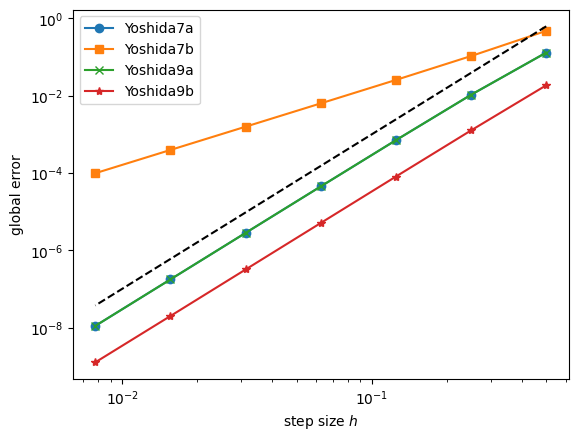

In [8]:
plt.loglog((tspan[1]-tspan[0])/nstep_array,global_error[0,:],marker='o',label='Yoshida7a')
plt.loglog((tspan[1]-tspan[0])/nstep_array,global_error[1,:],marker='s',label='Yoshida7b')
plt.loglog((tspan[1]-tspan[0])/nstep_array,global_error[2,:],marker='x',label='Yoshida9a')
plt.loglog((tspan[1]-tspan[0])/nstep_array,global_error[3,:],marker='*',label='Yoshida9b')
plt.loglog((tspan[1]-tspan[0])/nstep_array,1e+9/nstep_array**4,ls='--',color='black')
plt.legend()
matplot2tikz.save("RigidBody_order-plot.tex")
plt.xlabel(r'step size $h$')
plt.ylabel('global error')
plt.show()

# Plot: global error vs. CPU time (in seconds)

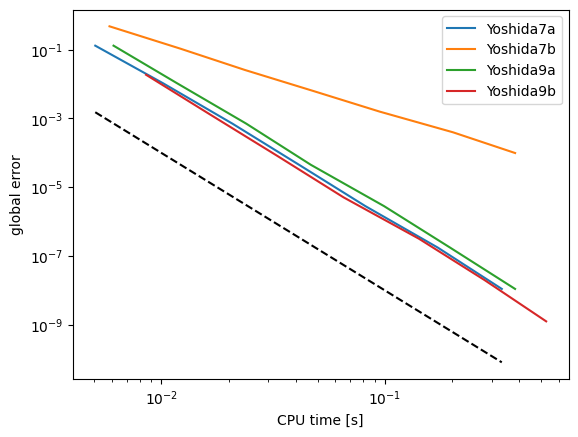

In [9]:
plt.loglog(CPU_times[0,:],global_error[0,:],label='Yoshida7a')
plt.loglog(CPU_times[1,:],global_error[1,:],label='Yoshida7b')
plt.loglog(CPU_times[2,:],global_error[2,:],label='Yoshida9a')
plt.loglog(CPU_times[3,:],global_error[3,:],label='Yoshida9b')
plt.loglog(CPU_times[0,:],1e-12/CPU_times[0,:]**4,ls='--',color='black')
plt.legend()
plt.xlabel('CPU time [s]')
plt.ylabel('global error')
plt.show()